In [1]:
import pandas as pd
import numpy as np
import pickle
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('data/processed/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('data/processed/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('data/processed/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('data/processed/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (564, 56)
Test set: (96, 56)


In [3]:
model = XGBClassifier(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [4]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9479166666666666
Precision: 0.9166666666666666
Recall: 0.88
F1 Score: 0.8979591836734694
ROC-AUC: 0.980281690140845


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.92      0.88      0.90        25

    accuracy                           0.95        96
   macro avg       0.94      0.93      0.93        96
weighted avg       0.95      0.95      0.95        96



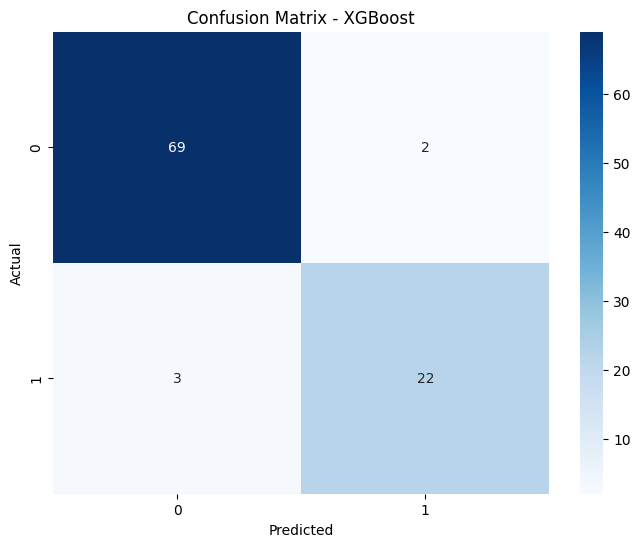

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [9]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(10)

,feature,importance
4,engagement_score,0.377707
5,is_absent_frequently,0.106283
16,NationalITy_KW,0.054627
1,VisITedResources,0.042781
6,parent_engaged,0.039238
44,Topic_French,0.031483
15,NationalITy_Jordan,0.030941
43,Topic_English,0.029510
9,StageID_encoded,0.026503
7,parent_satisfied,0.026192


In [10]:
with open('models/xgboost.pkl', 'wb') as f:
    pickle.dump(model, f)
